# QR Decomposition

## 1. QR Decomposition

The QR factorization is
$$
A=QR
$$
where the columns of $Q$ are orthonormal:
$$
Q^TQ=I
$$
The least-squares problem becomes
$$
\min_x\|QRx-b\|_2
$$

and can be reduced to the upper-triangular system
$$
Rx=Q^Tb
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=8)
rng = np.random.default_rng(7)

## 2. Hadamard Matrix

In [2]:
def hadamard_matrix(order):
    if order < 1 or order & (order - 1):
        raise ValueError(
            "Order must be a power of two."
        )

    H = np.array([[1.0]])

    while H.shape[0] < order:
        H = np.block([
            [H, H],
            [H, -H]
        ])

    return H

## 3. Classical Gram–Schmidt

$$
r_{ij}=q_i^Ta_j,
\qquad i<j
$$
$$
v_j
=
a_j-\sum_{i=1}^{j-1}r_{ij}q_i
$$
$$
r_{jj}=\|v_j\|_2
$$
$$
q_j=\frac{v_j}{r_{jj}}
$$

In [3]:
def qr_classical_gram_schmidt(A, tolerance=None):
    A_demo = np.asarray(A, dtype=float)

    if A_demo.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")

    if not np.all(np.isfinite(A_demo)):
        raise ValueError("A must contain only finite values.")

    m, n = A_demo.shape

    if m < n:
        raise ValueError(
            "Classical Gram-Schmidt requires m >= n "
            "to produce n orthonormal columns."
        )

    Q = np.zeros((m, n), dtype=float)
    R = np.zeros((n, n), dtype=float)

    if tolerance is None:
        tolerance = (
            np.finfo(float).eps* max(m, n)* max(np.linalg.norm(A_demo, ord=2), 1.0))

    for j in range(n):
        a_j = A_demo[:, j]

        if j > 0:
            R[:j, j] = Q[:, :j].T @ a_j
            v_j = a_j - Q[:, :j] @ R[:j, j]
        else:
            v_j = a_j.copy()

        R[j, j] = np.linalg.norm(v_j, ord=2)

        if R[j, j] <= tolerance:
            raise np.linalg.LinAlgError(
                "The columns of A are linearly dependent "
                "or numerically rank deficient."
            )

        Q[:, j] = v_j / R[j, j]

    return Q, R

In [4]:
rng = np.random.default_rng(7)
A = rng.normal(size=(6, 4))
Q, R = qr_classical_gram_schmidt(A)

assert np.allclose(A, Q @ R)
assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]))
assert np.allclose(R, np.triu(R))

print("Q =")
print(Q)
print("\nR =")
print(R)

Q =
[[ 0.00051712  0.20721713 -0.14561634 -0.36025909]
 [-0.19112915 -0.59345623  0.13250883  0.31272756]
 [-0.20690798 -0.32782076  0.59417969 -0.68901774]
 [ 0.0443128  -0.66827623 -0.32989422  0.09710742]
 [-0.56506508 -0.03626747 -0.65425693 -0.37397408]
 [-0.77420688  0.22247666  0.26703081  0.38520507]]

R =
[[ 2.37886678  0.71742847  1.94129496  0.21901133]
 [ 0.          1.43991253 -0.44655548 -1.45443628]
 [ 0.          0.          1.25403362  1.20607853]
 [ 0.          0.          0.          1.14832976]]


## 4. Modified Gram–Schmidt

In [5]:
def qr_modified_gram_schmidt(A, tolerance=None):
    A_demo = np.asarray(A, dtype=float)

    if A_demo.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")

    if not np.all(np.isfinite(A_demo)):
        raise ValueError("A must contain only finite values.")

    m, n = A_demo.shape

    if m < n:
        raise ValueError(
            "Modified Gram-Schmidt requires m >= n "
            "to produce n orthonormal columns."
        )

    Q = np.zeros((m, n), dtype=float)
    R = np.zeros((n, n), dtype=float)
    V = A_demo.copy()

    if tolerance is None:
        tolerance = (
            np.finfo(float).eps
            * max(m, n)
            * max(np.linalg.norm(A_demo, ord=2), 1.0)
        )

    for i in range(n):
        R[i, i] = np.linalg.norm(V[:, i], ord=2)

        if R[i, i] <= tolerance:
            raise np.linalg.LinAlgError(
                "The columns of A are linearly dependent "
                "or numerically rank deficient."
            )

        Q[:, i] = V[:, i] / R[i, i]

        for j in range(i + 1, n):
            R[i, j] = Q[:, i] @ V[:, j]
            V[:, j] = V[:, j] - R[i, j] * Q[:, i]

    return Q, R

In [6]:
rng = np.random.default_rng(7)
A = rng.normal(size=(6, 4))
Q, R = qr_modified_gram_schmidt(A)

assert np.allclose(A, Q @ R)
assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]))
assert np.allclose(R, np.triu(R))

print("Q =")
print(Q)
print("\nR =")
print(R)

Q =
[[ 0.00051712  0.20721713 -0.14561634 -0.36025909]
 [-0.19112915 -0.59345623  0.13250883  0.31272756]
 [-0.20690798 -0.32782076  0.59417969 -0.68901774]
 [ 0.0443128  -0.66827623 -0.32989422  0.09710742]
 [-0.56506508 -0.03626747 -0.65425693 -0.37397408]
 [-0.77420688  0.22247666  0.26703081  0.38520507]]

R =
[[ 2.37886678  0.71742847  1.94129496  0.21901133]
 [ 0.          1.43991253 -0.44655548 -1.45443628]
 [ 0.          0.          1.25403362  1.20607853]
 [ 0.          0.          0.          1.14832976]]


## 5. Householder Reflection

In [7]:
def qr_householder(A, tolerance=None):
    A_demo = np.asarray(A, dtype=float)

    if A_demo.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")

    if not np.all(np.isfinite(A_demo)):
        raise ValueError("A must contain only finite values.")

    m, n = A_demo.shape

    if m < n:
        raise ValueError(
            "Householder QR requires m >= n "
            "for a reduced QR decomposition."
        )
    if tolerance is None:
        tolerance = (
            np.finfo(float).eps
            * max(m, n)
            * max(np.linalg.norm(A_demo, ord=2), 1.0)
        )

    R = A_demo.copy()
    Q = np.eye(m)

    for k in range(n):
        x = R[k:, k]
        norm_x = np.linalg.norm(x, ord=2)

        if norm_x <= tolerance:
            raise np.linalg.LinAlgError(
                "The columns of A are linearly dependent "
                "or numerically rank deficient."
            )
        alpha = -np.copysign(norm_x, x[0])
        v = x.copy()
        v[0] -= alpha

        norm_v = np.linalg.norm(v, ord=2)
        if norm_v <= tolerance:
            raise np.linalg.LinAlgError(
                "Failed to construct a Householder vector."
            )


        v = v / norm_v
        H_small = (
            np.eye(m - k)
            - 2.0 * np.outer(v, v)
        )
        H = np.eye(m)
        H[k:, k:] = H_small
        R = H @ R
        Q = Q @ H.T
        R[k + 1:, k] = 0.0

    Q_reduced = Q[:, :n]
    R_reduced = np.triu(R[:n, :])

    return Q_reduced, R_reduced
    

In [8]:
rng = np.random.default_rng(7)
A = rng.normal(size=(6, 4))
Q, R = qr_householder(A)

assert np.allclose(A, Q @ R)
assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]))
assert np.allclose(R, np.triu(R))

print("Q =")
print(Q)
print("\nR =")
print(R)

Q =
[[-0.00051712  0.20721713  0.14561634 -0.36025909]
 [ 0.19112915 -0.59345623 -0.13250883  0.31272756]
 [ 0.20690798 -0.32782076 -0.59417969 -0.68901774]
 [-0.0443128  -0.66827623  0.32989422  0.09710742]
 [ 0.56506508 -0.03626747  0.65425693 -0.37397408]
 [ 0.77420688  0.22247666 -0.26703081  0.38520507]]

R =
[[-2.37886678 -0.71742847 -1.94129496 -0.21901133]
 [ 0.          1.43991253 -0.44655548 -1.45443628]
 [ 0.          0.         -1.25403362 -1.20607853]
 [ 0.          0.          0.          1.14832976]]


## 6. Error Analysis

### 6.1 Factorization Residual

The normalized factorization residual is

$$
\frac{\|A-QR\|_F}{\|A\|_F}.
$$

In [9]:
def qr_residual(A, Q, R):
    return (
        np.linalg.norm(A - Q @ R)
        / np.linalg.norm(A)
    )

### 6.2 Orthogonality Error

The orthogonality error is

$$
\|I-Q^TQ\|_F.
$$

In [10]:
def orthogonality_error(Q):
    n = Q.shape[1]

    return np.linalg.norm(
        np.eye(n) - Q.T @ Q
    )

## 7. Solving Least-Squares Problems with QR

Given
$$
A=QR
$$
the least-squares problem
$$
\min_x\|Ax-b\|_2
$$
becomes
$$
\min_x\|QRx-b\|_2
$$
Because the columns of $Q$ are orthonormal, the solution satisfies
$$
Rx=Q^Tb
$$

In [11]:
def backward_substitution(U, y, tolerance=None):
    U = np.asarray(U, dtype=float)
    y = np.asarray(y, dtype=float)

    if U.ndim != 2 or U.shape[0] != U.shape[1]:
        raise ValueError("U must be a square matrix.")

    if y.ndim != 1 or y.shape[0] != U.shape[0]:
        raise ValueError("y must be a vector compatible with U.")

    n = U.shape[0]

    if tolerance is None:
        tolerance = (
            np.finfo(float).eps
            * max(n, 1)
            * max(np.linalg.norm(U, ord=np.inf), 1.0)
        )

    x = np.zeros(n, dtype=float)

    for i in range(n - 1, -1, -1):
        if abs(U[i, i]) <= tolerance:
            raise np.linalg.LinAlgError(
                "The upper-triangular matrix is singular or rank deficient."
            )

        x[i] = (
            y[i] - U[i, i + 1:] @ x[i + 1:]
        ) / U[i, i]

    return x


def least_squares_qr(A, b, qr_method):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)

    if A.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")

    if b.ndim != 1 or b.shape[0] != A.shape[0]:
        raise ValueError("b must be a vector compatible with A.")

    Q, R = qr_method(A)

    right_hand_side = Q.T @ b

    x = backward_substitution(
        R,
        right_hand_side
    )

    return x

In [12]:
# Construct a reproducible overdetermined least-squares problem.
least_squares_rng = np.random.default_rng(21)
m_ls, n_ls = 30, 5
A_ls = least_squares_rng.normal(size=(m_ls, n_ls))
x_true = least_squares_rng.normal(size=n_ls)
b_ls = A_ls @ x_true + 0.01 * least_squares_rng.normal(size=m_ls)

least_squares_methods = {
    "Classical Gram-Schmidt": qr_classical_gram_schmidt,
    "Modified Gram-Schmidt": qr_modified_gram_schmidt,
    "Householder Reflection": qr_householder,
}

solutions = {}
least_squares_residuals = {}
normal_equation_errors = {}

for method_name, qr_method in least_squares_methods.items():
    x_value = least_squares_qr(A_ls, b_ls, qr_method)
    residual = b_ls - A_ls @ x_value

    solutions[method_name] = x_value
    least_squares_residuals[method_name] = (
        np.linalg.norm(residual, ord=2)
        / np.linalg.norm(b_ls, ord=2)
    )
    normal_equation_errors[method_name] = np.linalg.norm(
        A_ls.T @ residual,
        ord=2,
    )

x_reference, *_ = np.linalg.lstsq(A_ls, b_ls, rcond=None)

print("Reference solution from np.linalg.lstsq:")
print(x_reference)

for method_name, x_value in solutions.items():
    assert np.allclose(x_value, x_reference, rtol=1e-10, atol=1e-12)

    print(f"\n{method_name} solution:")
    print(x_value)
    print(
        f"Normalized residual: "
        f"{least_squares_residuals[method_name]:.3e}"
    )
    print(
        f"Normal-equation error: "
        f"{normal_equation_errors[method_name]:.3e}"
    )

Reference solution from np.linalg.lstsq:
[ 0.53380499 -0.20553456 -0.39863559 -0.18057446  1.09901046]

Classical Gram-Schmidt solution:
[ 0.53380499 -0.20553456 -0.39863559 -0.18057446  1.09901046]
Normalized residual: 5.734e-03
Normal-equation error: 6.899e-15

Modified Gram-Schmidt solution:
[ 0.53380499 -0.20553456 -0.39863559 -0.18057446  1.09901046]
Normalized residual: 5.734e-03
Normal-equation error: 1.037e-14

Householder Reflection solution:
[ 0.53380499 -0.20553456 -0.39863559 -0.18057446  1.09901046]
Normalized residual: 5.734e-03
Normal-equation error: 7.765e-15


## 8. Plotting and Comparison

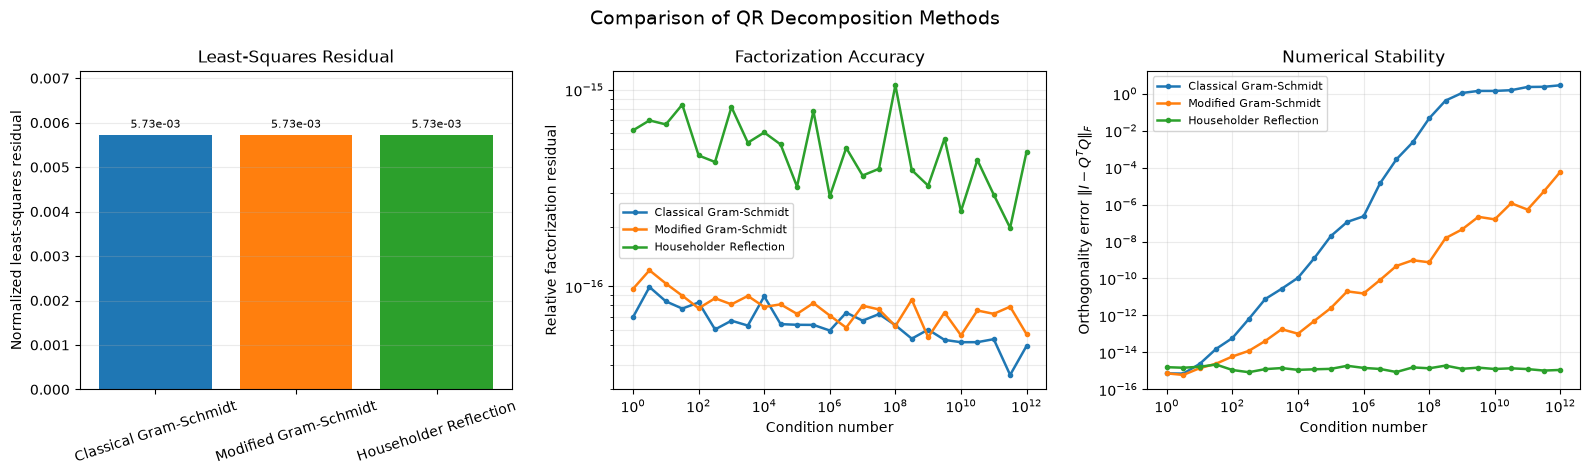

In [13]:
method_names = list(least_squares_methods.keys())
method_colors = ["tab:blue", "tab:orange", "tab:green"]

# Build matrices with controlled condition numbers.
stability_rng = np.random.default_rng(35)
m_stability, n_stability = 40, 8
U_stability, _ = np.linalg.qr(
    stability_rng.normal(size=(m_stability, n_stability)),
    mode="reduced",
)
V_stability, _ = np.linalg.qr(
    stability_rng.normal(size=(n_stability, n_stability))
)

condition_numbers = np.logspace(0, 12, 25)
factorization_residuals = {
    name: [] for name in method_names
}
orthogonality_errors = {
    name: [] for name in method_names
}

for condition_number in condition_numbers:
    singular_values = np.geomspace(
        1.0,
        1.0 / condition_number,
        n_stability,
    )
    A_conditioned = (
        U_stability
        @ np.diag(singular_values)
        @ V_stability.T
    )

    for method_name, qr_method in least_squares_methods.items():
        try:
            Q_value, R_value = qr_method(A_conditioned)
            factorization_residuals[method_name].append(
                qr_residual(A_conditioned, Q_value, R_value)
            )
            orthogonality_errors[method_name].append(
                orthogonality_error(Q_value)
            )
        except np.linalg.LinAlgError:
            factorization_residuals[method_name].append(np.nan)
            orthogonality_errors[method_name].append(np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Compare least-squares residuals for the verification problem.
residual_values = [
    least_squares_residuals[name] for name in method_names
]
bars = axes[0].bar(
    method_names,
    residual_values,
    color=method_colors,
)
axes[0].set_ylim(0.0, max(residual_values) * 1.25)
axes[0].set_ylabel("Normalized least-squares residual")
axes[0].set_title("Least-Squares Residual")
axes[0].tick_params(axis="x", rotation=18)
axes[0].grid(axis="y", alpha=0.25)
axes[0].bar_label(bars, fmt="%.2e", padding=3, fontsize=8)

# Compare QR factorization residuals as conditioning worsens.
for method_name, color in zip(method_names, method_colors):
    axes[1].loglog(
        condition_numbers,
        factorization_residuals[method_name],
        marker="o",
        markersize=3,
        linewidth=1.8,
        color=color,
        label=method_name,
    )

axes[1].set_xlabel("Condition number")
axes[1].set_ylabel("Relative factorization residual")
axes[1].set_title("Factorization Accuracy")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(fontsize=8)

# Orthogonality loss is the main numerical-stability indicator.
for method_name, color in zip(method_names, method_colors):
    axes[2].loglog(
        condition_numbers,
        orthogonality_errors[method_name],
        marker="o",
        markersize=3,
        linewidth=1.8,
        color=color,
        label=method_name,
    )

axes[2].set_xlabel("Condition number")
axes[2].set_ylabel(r"Orthogonality error $\|I-Q^TQ\|_F$")
axes[2].set_title("Numerical Stability")
axes[2].grid(True, which="both", alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("Comparison of QR Decomposition Methods", fontsize=14)
fig.tight_layout()
plt.show()